In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
factor = 2
# mpl.rcParams['font.size'] = 12*factor            # default size for all text
# mpl.rcParams['axes.titlesize'] = 14  *factor     # titles
# mpl.rcParams['axes.labelsize'] = 12  *factor     # axis labels
# mpl.rcParams['legend.fontsize'] = 10 *factor     # legend
# mpl.rcParams['xtick.labelsize'] = 10*factor
# mpl.rcParams['ytick.labelsize'] = 10*factor
plt.rcParams["font.family"] = "serif"

line_width_factor=2
plot_line_width=1.5*line_width_factor

In [115]:
PROJECT = "crl_rnn_craftax_classic_bug_fixed_final"
# env_ids = ["pick-place-v3", "assembly-v3", "stick-push-v3", "shelf-place-v3", "bin-picking-v3"]
# env_ids=["shelf-place-v3"]
env_ids = ["Craftax-Classic-Symbolic-v1"]
int_rew_sources=["crl_ppo_rnn", "E3B", "RND", "ICM", "Random_policy"]
def files_dict(env_id, int_rew_source):
    files_dirs = [f"{env_id}_{int_rew_source}.csv"]
    return  files_dirs


# merge dfs
dfs = []
for int_rew_source in int_rew_sources:
    for env_id in env_ids:
        for file in files_dict(env_id, int_rew_source):
            df = pd.read_csv(file)
            df["time/total_timesteps"]=np.linspace(0, int(1e9), len(df["achievements"]))
            dfs.append(df)

labels = {
    "TDD": "ETD",
    "CTEC": "C-TeC (Ours)",
    "crl_ppo_rnn": "C-TeC (Ours)",
    "E3B": "E3B",
    "RND": "RND",
    "ICM": "ICM",
    "Random Policy": "Random Policy",
    }



y_label={"rollout/number_of_visited_states": "# Visited States",
"achievements": "Achievements"}
x_label={"time/total_timesteps": "Environment Steps"}
df_final = pd.concat(dfs, axis=0)
env_names = {
    "ant_hardest_maze": "Ant hardest maze",
    "humanoid_u_maze": "Humanoid u maze", 
    "arm_binpick_hard": "Arm binpick hard",
    "Craftax-Classic-Symbolic-v1": "Craftax Classic"
}

In [108]:
df.columns

Index(['max_return_percentage', 'Achievements/collect_wood', '_timestamp',
       'Achievements/place_furnace', 'Achievements/collect_iron',
       'Achievements/collect_drink', 'achievements',
       'Achievements/place_table', 'Achievements/eat_plant', 'episode_length',
       'Achievements/eat_cow', 'Achievements/collect_coal',
       'Achievements/make_iron_sword', 'Achievements/make_iron_pickaxe',
       'Achievements/collect_diamond', 'Achievements/collect_sapling', '_step',
       '_runtime', 'Achievements/place_plant', 'Achievements/collect_stone',
       'Achievements/make_wood_sword', 'Achievements/place_stone',
       'Achievements/make_wood_pickaxe', 'Achievements/make_stone_pickaxe',
       'Achievements/make_stone_sword', 'Achievements/defeat_zombie', 'sps',
       'Achievements/wake_up', 'Achievements/defeat_skeleton',
       'episode_return', 'run_id', 'run_name', 'ENV_NAME', 'MODEL', 'SEED',
       'time/total_timesteps'],
      dtype='object')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_learning_curves(df, 
                         metric="rollout/number_of_visited_states",
                         xcol='time/total_timesteps',
                         env_col='game_name',
                         algo_col='int_rew_source',
                         run_col='run_id',
                         seed_col='seed',
                         MAX_POINTS=200,
                         figsize=(12, 3),
                         palette=None,
                         forward_fill=True,
                         log_x=False, 
                         use_xcol=True):
    """
    Plots one row per env, one curve per algo, mean ± std shading.
    - Drops NaNs in `metric` before interpolation.
    - Optionally forward/back-fills small gaps.
    """
    envs = (df[env_col].unique())
    algos = (df[algo_col].unique())
    
    if palette is None:
        palette = sns.color_palette("Dark2", n_colors=len(algos))
    algo_colors = dict(zip(algos, palette))
    # algo_colors = {"SAC_RM": palette[0], "SAC": palette[1] }
    # print(figsize[0]*len(envs))
    fig, axes = plt.subplots(1, len(envs), 
                             figsize=(10, 3),
                             constrained_layout=True)
    
    if len(envs) == 1:
        axes = [axes]
    
    for ind, (ax, env) in enumerate(zip(axes, envs)):
        env_df = df[df[env_col] == env]
        ax.set_title(env_names[env], fontsize=17.3, fontweight='bold')
        ax.set_xlabel("Environment Steps", fontsize=17.3)
        if ind==0:
            ax.set_ylabel(y_label[metric], fontsize=17.3)
        if log_x:
            ax.set_xscale('log')
        
        for algo in algos:
            sub_df = env_df[env_df[algo_col] == algo]
            if sub_df.empty:
                continue
            
            # Prepare grid limits from overlapping runs
            runs = sub_df[run_col].unique()
            if use_xcol:
                # compute the intersection of [min, max] across runs
                mins = sub_df.groupby(run_col)[xcol].min()
                maxs = sub_df.groupby(run_col)[xcol].max()
                xs_min = mins.max()
                xs_max = maxs.min()
                if xs_max <= xs_min:
                    xs_min, xs_max = sub_df[xcol].min(), sub_df[xcol].max()
                    x_grid = np.linspace(xs_min, xs_max, MAX_POINTS)
            else:
                x_grid = np.linspace(0, int(1e9), MAX_POINTS)
            
            # x_grid = np.linspace(xs_min, xs_max, MAX_POINTS)
            
            traces = []
            
            for run in runs:
                run_df = sub_df[sub_df[run_col] == run].sort_values(xcol)
                # keep only rows where metric is not null
                run_df = run_df[[xcol, metric]].dropna(subset=[metric])
                if run_df.shape[0] < 2:
                    continue
                
                # optional small-gap fill
                if forward_fill:
                    run_df = run_df.set_index(xcol).asfreq(
                        pd.infer_freq(run_df[xcol].astype(int).values), 
                        method='ffill', limit=5
                    ).reset_index()
                
                y = np.interp(x_grid, run_df[xcol], run_df[metric])
                # if run_df[xcol].max() < xs_max:
                last_val = run_df[metric].iloc[-1]
                y[x_grid > run_df[xcol].max()] = last_val
                traces.append(y)
            
            if not traces:
                continue
            
            arr = np.vstack(traces)
            mean = arr.mean(axis=0)
            std  = arr.std(axis=0)
            
            color = algo_colors[algo]
            
            ax.plot(x_grid, mean, label=labels[algo], color=color, lw=plot_line_width)
            ax.fill_between(x_grid, mean - std, mean + std,
                            color=color, alpha=0.25)
            ax.tick_params(axis='x', labelsize=12)  # x-axis ticks
            ax.tick_params(axis='y', labelsize=12)
            
        
        # ax.legend(title="", fontsize=8, title_fontsize=9, loc="upper center")
        handles, labels_ = axes[0].get_legend_handles_labels()
        # fig.legend(handles, labels_, loc="lower center", ncol=len(algos),
        #    bbox_to_anchor=(0.55, -0.25), fontsize="xx-large")
        # fig.legend(handles, labels_, loc="lower center", ncol=len(algos),
        #    bbox_to_anchor=(0.55, -0.25), fontsize="xx-large")
        

        ax.grid(True, which='both', ls='--', lw=0.5)
    # # Example data
    # crafter_labels = ["ETD", "C-TeC"]
    # means = [0.33, 2.03]
    # stds = [0.05, 0.29]

    # x = np.arange(len(crafter_labels))  # label locations
    # width = 0.8  # bar width
    # palette = sns.color_palette("tab10", n_colors=len(labels))[::-1]
    # algo_colors = dict(zip(crafter_labels, palette))
    # # Create bar plot
    # # plt.figure(figsize=(5, 3))
    # plt.rcParams['font.family'] = 'serif'
    # # fig, ax = plt.subplots(figsize=(3, 3))
    # ax = axes[-1]
    # bars = ax.bar(x, means, width, yerr=stds, capsize=5, color=palette,)

    # # Add labels and title
    # ax.set_ylabel('Crafter Score',  fontsize=17.3)
    # ax.set_title('Crafter', fontsize=17.3, fontweight='bold')
    # ax.set_xticks(x)
    # ax.set_xticklabels(crafter_labels,  fontsize=17.3)
    # ax.grid(True, axis='y', alpha=0.7)

    # fig.sa
    plt.savefig("etd_ctec_results.pdf", dpi=200, bbox_inches="tight")
    plt.savefig("etd_ctec_results.png", dpi=200, bbox_inches="tight")

    
    # plt.show()

In [124]:
plot_learning_curves(df_final, forward_fill=False, MAX_POINTS=500)
# plt.savefig("metaword_restuls.pdf", dpi=300)
# plt.savefig("metaword_restuls.png", dpi=300)

KeyError: 'game_name'

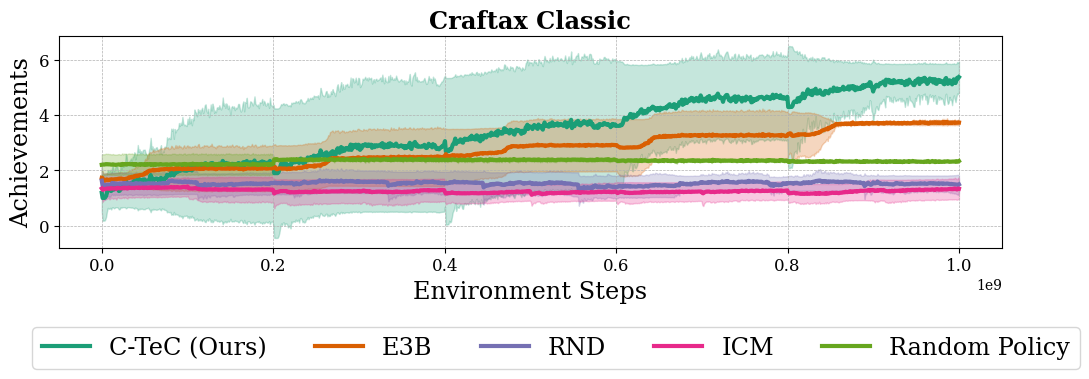

In [135]:
plot_learning_curves(df_final, metric="achievements", algo_col="MODEL", env_col="ENV_NAME",  forward_fill=False, MAX_POINTS=1000)
# plt.savefig("metaword_restuls.pdf", dpi=300)
# plt.savefig("metaword_restuls.png", dpi=300)

In [100]:
df_final["achievements"]

0       0.946210
1       0.007168
2       0.008197
3       0.016129
4       0.004484
          ...   
2495    2.357456
2496    2.320261
2497    2.350649
2498    2.363058
2499    2.433036
Name: achievements, Length: 17000, dtype: float64

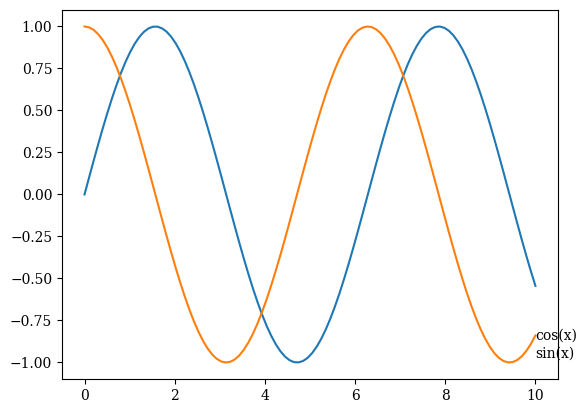

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

fig, ax = plt.subplots()

ax.plot(x, y1, label="sin(x)")
ax.plot(x, y2, label="cos(x)")

# Inline labels (choose last point for placement)
ax.text(x[-1], y1[-1], "sin(x)", va="center", ha="left", fontsize=10)
ax.text(x[-1], y2[-1], "cos(x)", va="center", ha="left", fontsize=10)

plt.show()
